In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/quyenle/Downloads/fraud-detection-modeling/dataset/transactions_clean.csv')
df.head(5)

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,737265056,5000,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,02,...,2015-03-14,2015-03-14,414,414,1803,PURCHASE,0.0,False,False,False
1,737265056,737265056,5000,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,09,...,2015-03-14,2015-03-14,486,486,767,PURCHASE,0.0,True,False,False
2,737265056,737265056,5000,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,09,...,2015-03-14,2015-03-14,486,486,767,PURCHASE,0.0,False,False,False
3,737265056,737265056,5000,5000.0,2016-12-10T02:14:50,7.47,Play Store,US,US,09,...,2015-03-14,2015-03-14,486,486,767,PURCHASE,0.0,False,False,False
4,830329091,830329091,5000,5000.0,2016-03-24T21:04:46,71.18,Tim Hortons #947751,US,US,02,...,2015-08-06,2015-08-06,885,885,3143,PURCHASE,0.0,True,False,False


### Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             786363 non-null  int64  
 1   customerId                786363 non-null  int64  
 2   creditLimit               786363 non-null  int64  
 3   availableMoney            786363 non-null  float64
 4   transactionDateTime       786363 non-null  object 
 5   transactionAmount         786363 non-null  float64
 6   merchantName              786363 non-null  object 
 7   acqCountry                786363 non-null  object 
 8   merchantCountryCode       786363 non-null  object 
 9   posEntryMode              786363 non-null  object 
 10  posConditionCode          786363 non-null  object 
 11  merchantCategoryCode      786363 non-null  object 
 12  currentExpDate            786363 non-null  object 
 13  accountOpenDate           786363 non-null  o

Let's take a look at these categorical features:
- accountNumber
- customerId
- creditLimit
- cardCVV
- enteredCVV
- cardLast4Digits

In [4]:
df[['accountNumber', 'customerId', 'creditLimit',  'cardCVV', 'enteredCVV', 'cardLast4Digits']].head(5)

,accountNumber,customerId,creditLimit,cardCVV,enteredCVV,cardLast4Digits
0,737265056,737265056,5000,414,414,1803
1,737265056,737265056,5000,486,486,767
2,737265056,737265056,5000,486,486,767
3,737265056,737265056,5000,486,486,767
4,830329091,830329091,5000,885,885,3143


In [5]:
df[['accountNumber', 'customerId', 'creditLimit',  'cardCVV', 'enteredCVV', 'cardLast4Digits']].nunique()

accountNumber      5000
customerId         5000
creditLimit          10
cardCVV             899
enteredCVV          976
cardLast4Digits    5245
dtype: int64

In [6]:
#Check if accountNumber and customerId are the same for all rows
df[(df['accountNumber']) != (df['customerId'])]

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud


accountNumber and customerId are the same across all rows. I will drop accountNumber from the dataset to reduce redundancy.

In [7]:
df = df.drop(['accountNumber'], axis=1)

customerId is categorical variable but is stored as integer because of its numerical format. I will convert it to categorical type.

In [8]:
#Convert numerical type to categorical type
df['customerId'] = df['customerId'].astype('category')

In [52]:
#Convert transactionDateTime from categorical to datetime type
df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])

In [9]:
df=df.drop(columns=['cardLast4Digits', 'enteredCVV', 'cardCVV'], axis=1)

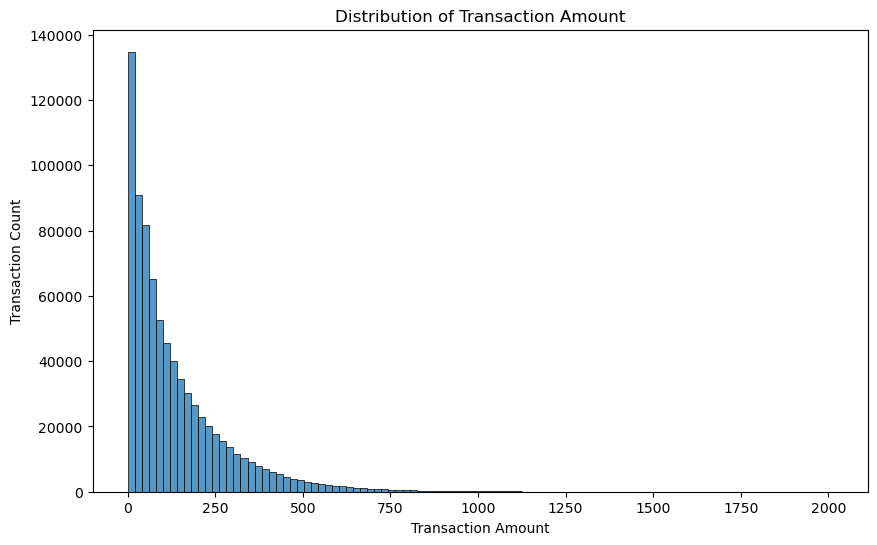

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df["transactionAmount"], bins=100)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Count")
plt.show()

To analyze categorical variables more effectively, I will create a reusable function called explore_categorical that I can apply to each variable in the dataset.

I want to see:

- how frequent each category is
- how fraud is distributed across categories

In [35]:
def fraud_rate_table(df, col):
    result = (
        df.groupby(col)
        .agg(
            transaction_count=("isFraud", "count"),
            fraud_count=("isFraud", "sum"),
            fraud_rate=("isFraud", "mean")
        )
        .sort_values("fraud_rate", ascending=False)
    )
    return result

In [36]:
fraud_rate_table(df, "merchantCategoryCode").head(15)

,transaction_count,fraud_count,fraud_rate
merchantCategoryCode,,,
airline,15412,534,0.034648
rideshare,51136,1272,0.024875
online_retail,202156,4938,0.024427
online_gifts,66238,1606,0.024246
furniture,7432,103,0.013859
food,75490,1014,0.013432
auto,21651,273,0.012609
entertainment,80098,961,0.011998
fastfood,112138,1074,0.009577


In [37]:
fraud_rate_table(df, "transactionType")

,transaction_count,fraud_count,fraud_rate
transactionType,,,
Unknown,698,14,0.020057
REVERSAL,20303,337,0.016599
PURCHASE,745193,11950,0.016036
ADDRESS_VERIFICATION,20169,116,0.005751


In [38]:
fraud_rate_table(df, "posEntryMode")

,transaction_count,fraud_count,fraud_rate
posEntryMode,,,
Unknown,4054,269,0.066354
09,236481,5659,0.023930
90,19576,372,0.019003
02,195934,3421,0.017460
80,15283,240,0.015704
05,315035,2456,0.007796


In [39]:
fraud_rate_table(df, "cardPresent")

,transaction_count,fraud_count,fraud_rate
cardPresent,,,
False,433495,8962,0.020674
True,352868,3455,0.009791


In [40]:
fraud_rate_table(df, "merchantName")

,transaction_count,fraud_count,fraud_rate
merchantName,,,
In-N-Out #949129,89,10,0.112360
American Airlines,3139,295,0.093979
In-N-Out #863086,96,9,0.093750
In-N-Out #463194,96,8,0.083333
In-N-Out #422833,110,9,0.081818
...,...,...,...
Quizno's #906442,96,0,0.000000
Golds Gym #741574,30,0,0.000000
Quizno's #876657,106,0,0.000000


In [41]:
fraud_rate_table(df, "creditLimit")

,transaction_count,fraud_count,fraud_rate
creditLimit,,,
15000,139307,2545,0.018269
5000,201863,3527,0.017472
50000,48781,841,0.017240
500,27097,465,0.017161
1000,36430,546,0.014988
2500,75429,1116,0.014795
10000,56889,766,0.013465
20000,68629,914,0.013318
7500,97913,1290,0.013175


In [43]:
fraud_rate_table(df, "merchantCountryCode")

,transaction_count,fraud_count,fraud_rate
merchantCountryCode,,,
Unknown,724,82,0.113260
CAN,2426,56,0.023083
MEX,3143,64,0.020363
PR,1559,27,0.017319
US,778511,12188,0.015656


In [44]:
fraud_rate_table(df, "expirationDateKeyInMatch")

,transaction_count,fraud_count,fraud_rate
expirationDateKeyInMatch,,,
False,785320,12404,0.015795
True,1043,13,0.012464


In [55]:
df.groupby('merchantCategoryCode')['transactionAmount'].describe().sort_values(['count'],ascending=False)

,count,mean,std,min,25%,50%,75%,max
merchantCategoryCode,,,,,,,,
online_retail,202156.0,145.231632,150.212475,0.0,38.7400,98.950,202.4250,2011.54
fastfood,112138.0,145.591507,149.858759,0.0,39.0700,99.485,203.0875,1905.30
entertainment,80098.0,146.041694,150.233520,0.0,38.9725,100.120,203.4475,1562.32
food,75490.0,145.313906,150.123692,0.0,38.5700,98.680,202.2375,1873.97
online_gifts,66238.0,146.126042,150.267402,0.0,38.7700,99.970,203.8475,1566.37
rideshare,51136.0,146.220783,150.376645,0.0,39.0875,100.080,204.6400,1398.23
hotels,34097.0,145.585076,150.498032,0.0,38.2200,99.730,202.4400,1546.48
fuel,23910.0,45.180771,15.608603,0.0,34.2425,45.870,56.9400,82.57
subscriptions,22901.0,146.900673,150.201653,0.0,39.5200,100.800,206.6100,1440.01


### Continous Variables

In [45]:
df.describe()

,creditLimit,availableMoney,transactionAmount,currentBalance
count,786363.000000,786363.000000,786363.000000,786363.000000
mean,10759.464459,6250.725369,136.985791,4508.739089
std,11636.174890,8880.783989,147.725569,6457.442068
min,250.000000,-1005.630000,0.000000,0.000000
25%,5000.000000,1077.420000,33.650000,689.910000
50%,7500.000000,3184.860000,87.900000,2451.760000
75%,15000.000000,7500.000000,191.480000,5291.095000
max,50000.000000,50000.000000,2011.540000,47498.810000


In [46]:
corr = df[['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']].corr()
corr.style.background_gradient()

,creditLimit,availableMoney,transactionAmount,currentBalance
creditLimit,1.000000,0.834977,0.005581,0.653652
availableMoney,0.834977,1.000000,-0.010070,0.129332
transactionAmount,0.005581,-0.010070,1.000000,0.023905
currentBalance,0.653652,0.129332,0.023905,1.000000


In [88]:
#Summary statistics for transactionAmount
df.groupby('isFraud')['transactionAmount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
False,773946.0,135.570249,146.525305,0.0,33.19,86.76,189.39,2011.54
True,12417.0,225.215905,189.551393,0.0,86.00,176.98,311.46,1608.35


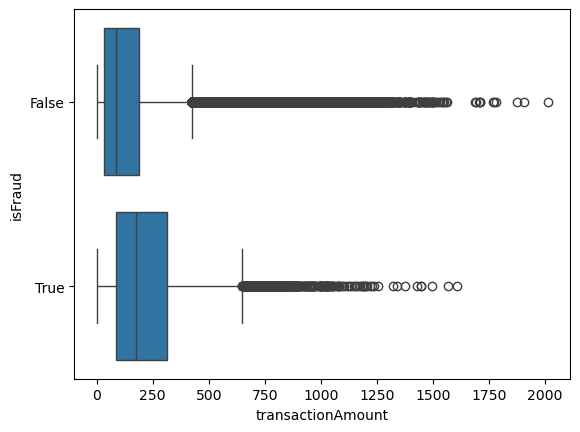

In [90]:
sns.boxplot(x='transactionAmount', y='isFraud', data=df, orient="h")
plt.show()

- Fraudulent transactions have a higher average transaction amount (mean ≈ 225) compared to non-fraudulent ones (mean ≈ 135).
- The median (50%) and upper quartile (75%) values are also notably higher for fraud cases.

In [47]:
print((df['transactionAmount'] == 0).sum())
df[df['transactionAmount'] == 0]['isFraud'].value_counts(normalize=True)

22225


isFraud
False    0.994511
True     0.005489
Name: proportion, dtype: float64

- There are 22,225 transactions that are $0. 
- Only 0.55% of these transactions are frauds so I will not take this into consideration.

In [48]:
#Summary statistics for currentBalance
df.groupby('isFraud')['currentBalance'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
False,773946.0,4502.428675,6446.866656,0.0,688.0325,2446.94,5286.10,47498.81
True,12417.0,4902.064338,7074.701649,0.0,822.2100,2747.39,5644.35,47473.94


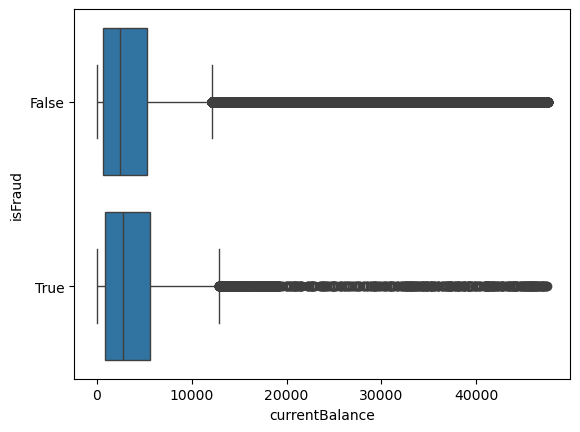

In [49]:
sns.boxplot(x='currentBalance', y='isFraud', data=df, orient="h")
plt.show()

In [50]:
#Summary statistics for availableMoney
df.groupby('isFraud')['availableMoney'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
False,773946.0,6252.455386,8883.600096,-1005.63,1077.42,3186.145,7500.00,50000.0
True,12417.0,6142.894186,8703.131117,-614.39,1078.02,3120.950,7502.82,50000.0


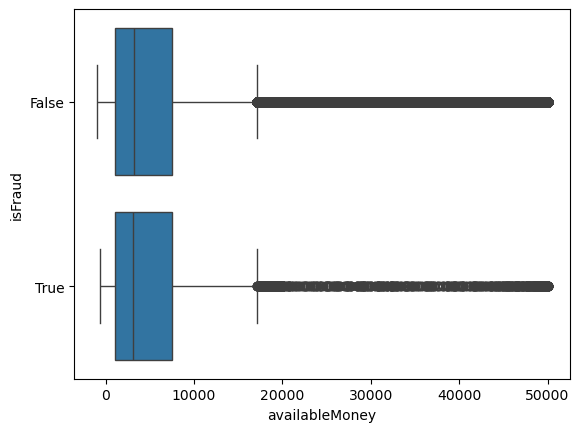

In [51]:
sns.boxplot(x='availableMoney', y='isFraud', data=df, orient="h")
plt.show()

- Fraudulent and non-fraudulent distributions for availableMoney and currentBalance are very similar in terms of mean, median, and spread.
- The boxplots show almost overlapping distributions, with many outliers.

### Handling duplicated reversal transactions

There are 2 types of duplicated transactions in this dataset:
- duplicates of reversed transaction, where a purchase is followed by a reversal. 
- multi-swipe, where a vendor accidentally charges a customer's card multiple times within a short time span.

I will identify these transactions and calculate total number and total dollar amount of them.

Reversal transactions should have the same customerID, merchantName and transactionAmount of their corresponding purchase transactions. Hence, it would be helpful to sort the dataset by customerId, merchantName with chronological order (by transactionDateTime).

In [57]:
df = df.sort_values(by=['customerId', 'merchantName','transactionDateTime'])
df = df.reset_index()
df = df.drop(columns = 'index')

In [58]:
df['transactionType'].value_counts()

transactionType
PURCHASE                745193
REVERSAL                 20303
ADDRESS_VERIFICATION     20169
Unknown                    698
Name: count, dtype: int64

Approach 1: we can remove duplicate transactions by checking if two consecutive transactions (one purchase and one reversal in that order) of the newly sorted df have the same customerId, merchantName, and transactionAmount

In [59]:
#array of all reversal transactions' index
rvs_idx=df[df['transactionType']=='REVERSAL'].index.values.astype(int)
rvs_idx

array([    13,    126,    142, ..., 786232, 786244, 786297])

In [61]:
#creating temporary df that contains the needed attributes for comparision
temp=df[['customerId','transactionAmount', 'merchantName','transactionType','transactionDateTime']]

In [62]:
#temporary df with all reversal transactions
temp_rvs = temp.iloc[rvs_idx]
temp_rvs.head()

,customerId,transactionAmount,merchantName,transactionType,transactionDateTime
13,100088067,22.32,AMC #79863,REVERSAL,2016-11-20 08:00:04
126,100328049,43.74,Lyft,REVERSAL,2016-01-15 20:36:18
142,100328049,284.97,McDonalds #423357,REVERSAL,2016-03-26 17:35:09
268,100737756,93.67,34th BBQ #436606,REVERSAL,2016-06-06 22:56:52
284,100737756,501.29,Best Bistro #262998,REVERSAL,2016-08-24 20:21:19


In [63]:
#temporary df of the transactions right before each reversal transaction.
temp_pch = temp.iloc[rvs_idx-1]
temp_pch.head()

,customerId,transactionAmount,merchantName,transactionType,transactionDateTime
12,100088067,22.32,AMC #79863,PURCHASE,2016-11-20 07:57:05
125,100328049,43.74,Lyft,PURCHASE,2016-01-15 20:34:35
141,100328049,284.97,McDonalds #423357,PURCHASE,2016-03-24 22:57:15
267,100737756,93.67,34th BBQ #436606,PURCHASE,2016-05-30 00:42:32
283,100737756,501.29,Best Bistro #262998,PURCHASE,2016-08-11 09:20:41


By taking a quick look at the first 5 data points of temp_rvs and temp_pch, we can see that all 5 reversal transactions in temp_rvs are duplicate as they come from the same customer in temp_pch with the same transactionAmount and merchantName

In [64]:
#Reset the index for row comparision
temp_rvs = temp_rvs.reset_index()
temp_pch = temp_pch.reset_index()

In [65]:
#cond_1: transactions must come from the same customerId
cond_1 = (temp_rvs.customerId == temp_pch.customerId)
#cond_2: transactions must have the same amount
cond_2 = (temp_rvs.transactionAmount == temp_pch.transactionAmount)
#cond_3: transaction must have the same merchantName
cond_3 = (temp_rvs.merchantName == temp_pch.merchantName)
#Combining all conditions
if_duplicate_1 = (cond_1 & cond_2 & cond_3)

In [66]:
if_duplicate_1.value_counts()

True     13016
False     7287
Name: count, dtype: int64

Checking the result by printing all duplicate transactions, we see that each reversal transaction in duplicate_rvs has a similar purchase transaction, which are consecutive (by index value in the sorted dataframe at the begining of Q3)

In [67]:
temp_rvs['if_duplicate'] = if_duplicate_1
temp_pch['if_duplicate'] = if_duplicate_1

In [68]:
duplicate_rvs = temp_rvs[temp_rvs['if_duplicate']==True]
duplicate_rvs

,index,customerId,transactionAmount,merchantName,transactionType,transactionDateTime,if_duplicate
0,13,100088067,22.32,AMC #79863,REVERSAL,2016-11-20 08:00:04,True
1,126,100328049,43.74,Lyft,REVERSAL,2016-01-15 20:36:18,True
2,142,100328049,284.97,McDonalds #423357,REVERSAL,2016-03-26 17:35:09,True
3,268,100737756,93.67,34th BBQ #436606,REVERSAL,2016-06-06 22:56:52,True
4,284,100737756,501.29,Best Bistro #262998,REVERSAL,2016-08-24 20:21:19,True
...,...,...,...,...,...,...,...
20298,786189,999258704,72.93,gap.com,REVERSAL,2016-09-02 03:33:07,True
20299,786226,999283629,247.40,Delta Airlines,REVERSAL,2016-05-01 05:42:19,True
20300,786232,999283629,150.58,Franks Sandwitch Bar,REVERSAL,2016-11-19 18:48:08,True
20301,786244,999283629,96.56,Lyft,REVERSAL,2016-06-07 18:32:39,True


In [69]:
duplicate_pch = temp_pch[temp_pch['if_duplicate']==True]
duplicate_pch

,index,customerId,transactionAmount,merchantName,transactionType,transactionDateTime,if_duplicate
0,12,100088067,22.32,AMC #79863,PURCHASE,2016-11-20 07:57:05,True
1,125,100328049,43.74,Lyft,PURCHASE,2016-01-15 20:34:35,True
2,141,100328049,284.97,McDonalds #423357,PURCHASE,2016-03-24 22:57:15,True
3,267,100737756,93.67,34th BBQ #436606,PURCHASE,2016-05-30 00:42:32,True
4,283,100737756,501.29,Best Bistro #262998,PURCHASE,2016-08-11 09:20:41,True
...,...,...,...,...,...,...,...
20298,786188,999258704,72.93,gap.com,PURCHASE,2016-09-02 03:31:57,True
20299,786225,999283629,247.40,Delta Airlines,PURCHASE,2016-04-09 12:56:52,True
20300,786231,999283629,150.58,Franks Sandwitch Bar,PURCHASE,2016-11-14 23:10:41,True
20301,786243,999283629,96.56,Lyft,PURCHASE,2016-06-01 23:34:21,True


There are 13016 duplicate transactions by finding two consecutive transactions (one reversal and one purchase) that have the same customerId,transactionAmount, and merchantName. However, we need to investigate and find the corresponding purchase transactions of the other 7287 reversal transactions.

Approach 2: Perform an iterative process to consider each of 7287 reversal transactions, check if we can find a purchase transaction that has the similar value for customerId, transactionAmount and merchantName

In [71]:
rvs_idx_2 = np.where(if_duplicate_1 == False)
#temporary df reversal transactions excluding the duplicate ones found above
temp_rvs_2 = temp_rvs.iloc[rvs_idx_2]

In [72]:
#notice that the number of row in this dataset should match the number of false values 
#of if_duplicate_1
temp_rvs_2

,index,customerId,transactionAmount,merchantName,transactionType,transactionDateTime,if_duplicate
8,609,101380713,0.00,Lyft,REVERSAL,2016-12-13 17:22:58,False
9,683,101380713,5.03,sears.com,REVERSAL,2016-06-22 22:10:22,False
14,866,101661970,18.15,American Airlines,REVERSAL,2016-04-24 14:03:36,False
15,1070,101738384,174.92,discount.com,REVERSAL,2016-03-17 05:37:44,False
16,1164,101738384,69.17,sears.com,REVERSAL,2016-07-05 15:24:57,False
...,...,...,...,...,...,...,...
20287,785788,999086814,159.82,Uber,REVERSAL,2016-10-12 23:26:19,False
20288,785789,999086814,301.80,Uber,REVERSAL,2016-10-14 16:18:46,False
20290,785819,999086814,57.27,Uber,REVERSAL,2016-12-01 22:40:23,False
20292,786021,999257059,33.06,Oklahoma City Times,REVERSAL,2016-05-19 04:16:19,False


In [73]:
#create a df with all purchase transaction
temp_purchase = temp[temp['transactionType']=='PURCHASE']

In [75]:
idx_rvs_duplicate = []
idx_pch_duplicate = []
for idx in temp_rvs_2['index']:
    
    #declare the variable corresponding to each unique index of the reversal transaction
    account = temp_rvs_2[temp_rvs_2['index']==idx]['customerId'].values[0]
    amount = temp_rvs_2[temp_rvs_2['index']==idx]['transactionAmount'].values[0]
    merchant = temp_rvs_2[temp_rvs_2['index']==idx]['merchantName'].values[0]
    
    result = temp_purchase[temp_purchase['customerId']==account]
    result = result[result['transactionAmount']==amount]
    result = result[result['merchantName']==merchant]
    
    # If there is a purchase transaction that matches all 3 variables, we found it!
    if result.shape[0] == 1:
        #append to idx_rvs_duplicate
        idx_rvs_duplicate.append(idx)
        #append to idx_pch_duplicate
        idx_pch = result.index.values[0]
        idx_pch_duplicate.append(idx_pch)

Checking the result by printing all duplicate transactions, we see that each reversal transaction in duplicate_rvs_2 has a similar purchase transaction in duplicate_pch_2, which are consecutive (by index value in the sorted dataframe at the begining)

In [76]:
duplicate_rvs_2 = temp.iloc[idx_rvs_duplicate]
duplicate_rvs_2

,customerId,transactionAmount,merchantName,transactionType,transactionDateTime
1070,101738384,174.92,discount.com,REVERSAL,2016-03-17 05:37:44
1164,101738384,69.17,sears.com,REVERSAL,2016-07-05 15:24:57
1189,101738384,954.71,staples.com,REVERSAL,2016-06-11 00:47:21
1456,101876201,30.52,staples.com,REVERSAL,2016-01-16 12:21:28
2091,102755773,81.69,gap.com,REVERSAL,2016-10-27 16:00:25
...,...,...,...,...,...
785705,999086814,251.25,Uber,REVERSAL,2016-06-24 16:42:36
785721,999086814,20.37,Uber,REVERSAL,2016-07-14 11:20:27
785788,999086814,159.82,Uber,REVERSAL,2016-10-12 23:26:19
785789,999086814,301.80,Uber,REVERSAL,2016-10-14 16:18:46


In [77]:
duplicate_pch_2 = temp.iloc[idx_pch_duplicate]
duplicate_pch_2

,customerId,transactionAmount,merchantName,transactionType,transactionDateTime
1068,101738384,174.92,discount.com,PURCHASE,2016-03-03 19:51:21
1162,101738384,69.17,sears.com,PURCHASE,2016-06-19 18:33:22
1186,101738384,954.71,staples.com,PURCHASE,2016-05-26 07:14:32
1454,101876201,30.52,staples.com,PURCHASE,2016-01-01 02:47:25
2089,102755773,81.69,gap.com,PURCHASE,2016-10-08 21:12:06
...,...,...,...,...,...
785702,999086814,251.25,Uber,PURCHASE,2016-06-23 15:23:08
785703,999086814,20.37,Uber,PURCHASE,2016-06-23 19:26:02
785785,999086814,159.82,Uber,PURCHASE,2016-10-08 14:02:52
785780,999086814,301.80,Uber,PURCHASE,2016-10-03 19:32:12


Out of 7287 reversal transactions after first approach, we find 5016 transactions that have corresponding purchase transactions. There are totally 13016 + 5016 = 18032 duplicate transactions, which is 18032/20303 = 88.81% of all reversal transactions. For 7287 - 5016 = 2271 reversal transactions that are not duplicate transactions, I believe they will have corresponding address_verification transactions, but we are not interested in this case

In [78]:
duplicate_rvs.head()

,index,customerId,transactionAmount,merchantName,transactionType,transactionDateTime,if_duplicate
0,13,100088067,22.32,AMC #79863,REVERSAL,2016-11-20 08:00:04,True
1,126,100328049,43.74,Lyft,REVERSAL,2016-01-15 20:36:18,True
2,142,100328049,284.97,McDonalds #423357,REVERSAL,2016-03-26 17:35:09,True
3,268,100737756,93.67,34th BBQ #436606,REVERSAL,2016-06-06 22:56:52,True
4,284,100737756,501.29,Best Bistro #262998,REVERSAL,2016-08-24 20:21:19,True


In [79]:
#reset index for duplicate_rvs_2 to match format with duplicate_rvs
duplicate_rvs_2 = duplicate_rvs_2.reset_index()
duplicate_rvs_2.head()

,index,customerId,transactionAmount,merchantName,transactionType,transactionDateTime
0,1070,101738384,174.92,discount.com,REVERSAL,2016-03-17 05:37:44
1,1164,101738384,69.17,sears.com,REVERSAL,2016-07-05 15:24:57
2,1189,101738384,954.71,staples.com,REVERSAL,2016-06-11 00:47:21
3,1456,101876201,30.52,staples.com,REVERSAL,2016-01-16 12:21:28
4,2091,102755773,81.69,gap.com,REVERSAL,2016-10-27 16:00:25


In [80]:
sum_amount_approach_1 = temp.iloc[duplicate_rvs['index']]['transactionAmount'].sum()
print(sum_amount_approach_1)

1900955.9700000002


In [81]:
sum_amount_approach_2 = temp.iloc[duplicate_rvs_2['index']]['transactionAmount'].sum()
print(sum_amount_approach_2)

749819.32


In [82]:
#total amount of all duplicate transactions:
print(sum_amount_approach_1 + sum_amount_approach_2 )

2650775.29


After finding all possible reversed transactions with 2 approaches, we found 17812 duplicate transactions, which is worth 2,650,775.29 dollars

I added a new column called `isDuplicate`. The purpose of this column is to mark whether each transaction is considered duplicate-like or normal

In [111]:
# Add duplicate flag column
df["isDuplicate"] = False

# Mark reversal duplicate transactions found by approach 1
df.loc[duplicate_rvs["index"], "isDuplicate"] = True

# Mark reversal duplicate transactions found by approach 2
df.loc[duplicate_rvs_2["index"], "isDuplicate"] = True

# Check result
df["isDuplicate"].value_counts()

isDuplicate
False    768331
True      18032
Name: count, dtype: int64

#### Handling Multiple Swipes

In [112]:
trans = df[
    (df["isDuplicate"] == False) &
    (df["transactionType"] == "PURCHASE")
][[
    "customerId",
    "transactionDateTime",
    "transactionAmount",
    "merchantName",
    "transactionType"
]].copy()

trans = trans.reset_index()
trans

,index,customerId,transactionDateTime,transactionAmount,merchantName,transactionType
0,0,100088067,2016-04-08 19:56:36,200.12,1st BBQ,PURCHASE
1,1,100088067,2016-11-09 07:26:06,95.11,1st Pub,PURCHASE
2,2,100088067,2016-05-06 02:54:01,5.26,1st Sandwitch Bar #758805,PURCHASE
3,3,100088067,2016-02-03 04:48:54,141.60,34th BBQ #412895,PURCHASE
4,4,100088067,2016-06-03 18:50:55,304.15,AMC #191138,PURCHASE
...,...,...,...,...,...,...
745188,786358,999389635,2016-10-23 16:47:41,4.62,Play Store,PURCHASE
745189,786359,999389635,2016-11-24 00:21:46,4.62,Play Store,PURCHASE
745190,786360,999389635,2016-12-24 05:19:30,4.62,Play Store,PURCHASE
745191,786361,999389635,2016-08-04 20:27:36,42.98,oldnavy.com,PURCHASE


Approach: I would define multiple-swipe transactions as two transactions that have the same customerId, transactionAmount and merchantName within 2 minutes (transactionDateTime) from each other

In [113]:
#Group by 'customerId', 'merchantName','transactionAmount' to consider transactions with same values
#Also, if the difference between transactionDateTime is less than 2 min, it is multiple-swipe transaction
trans['if_multiple_swipe'] = trans.groupby(['customerId', 'merchantName','transactionAmount'])['transactionDateTime'].diff().dt.total_seconds().lt(120)

/var/folders/b5/pkdzczfd4472yxqltrm5gj080000gn/T/ipykernel_24884/3183194128.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trans['if_multiple_swipe'] = trans.groupby(['customerId', 'merchantName','transactionAmount'])['transactionDateTime'].diff().dt.total_seconds().lt(120)


In [114]:
#take the index of multiple-swipe transaction
mult_swipe_idx = trans[trans['if_multiple_swipe']==True]['index']

In [115]:
#original transactions (the normal ones)
normal = trans[trans['index'].isin(mult_swipe_idx-1)]
normal

,index,customerId,transactionDateTime,transactionAmount,merchantName,transactionType,if_multiple_swipe
43,44,100088067,2016-10-16 18:01:00,411.35,Fresh Flowers,PURCHASE,False
250,257,100737756,2016-07-10 14:31:07,43.25,34th BBQ #166379,PURCHASE,False
317,332,100737756,2016-01-18 01:55:24,693.50,Franks Deli,PURCHASE,False
373,388,100737756,2016-07-02 12:05:04,211.22,South Steakhouse #73819,PURCHASE,False
443,458,101132326,2016-08-24 02:09:08,188.86,Regal Cinemas #05791,PURCHASE,False
...,...,...,...,...,...,...,...
744275,785388,999086814,2016-05-07 17:56:19,49.44,Lyft,PURCHASE,False
744404,785532,999086814,2016-11-28 08:26:31,356.16,Lyft,PURCHASE,False
744717,785863,999086814,2016-12-19 02:48:24,22.76,apple.com,PURCHASE,False
744798,785949,999086814,2016-08-04 00:02:27,172.50,staples.com,PURCHASE,False


In [116]:
mult_swipe = trans[trans['index'].isin(mult_swipe_idx)]
mult_swipe

,index,customerId,transactionDateTime,transactionAmount,merchantName,transactionType,if_multiple_swipe
44,45,100088067,2016-10-16 18:01:02,411.35,Fresh Flowers,PURCHASE,True
251,258,100737756,2016-07-10 14:32:06,43.25,34th BBQ #166379,PURCHASE,True
318,333,100737756,2016-01-18 01:55:28,693.50,Franks Deli,PURCHASE,True
374,389,100737756,2016-07-02 12:07:00,211.22,South Steakhouse #73819,PURCHASE,True
444,459,101132326,2016-08-24 02:09:44,188.86,Regal Cinemas #05791,PURCHASE,True
...,...,...,...,...,...,...,...
744276,785389,999086814,2016-05-07 17:56:48,49.44,Lyft,PURCHASE,True
744405,785533,999086814,2016-11-28 08:28:01,356.16,Lyft,PURCHASE,True
744718,785864,999086814,2016-12-19 02:49:22,22.76,apple.com,PURCHASE,True
744799,785950,999086814,2016-08-04 00:04:03,172.50,staples.com,PURCHASE,True


It seems like this approach works as all transactions in mult_swipe dataframe actually appear in normal dataframe with the same value of customerId, transactionAmount, merchantName within 2 mintues period of transactionDateTime

In [117]:
trans[trans['if_multiple_swipe']==True]['transactionAmount'].sum()

738267.73

We found 4893 multiple-swipe transactions, which is worth 738,267.73 dollars

In [118]:
# Add isMultiSwipe column to original df
df["isMultiSwipe"] = False

# Mark multi-swipe duplicate transactions in original df
df.loc[mult_swipe_idx, "isMultiSwipe"] = True

# Also update the general duplicate flag
df.loc[mult_swipe_idx, "isDuplicate"] = True

# Check results
print("Multi-swipe transaction count:", df["isMultiSwipe"].sum())
print(
    "Multi-swipe transaction amount:",
    df.loc[df["isMultiSwipe"] == True, "transactionAmount"].sum()
)

Multi-swipe transaction count: 4893
Multi-swipe transaction amount: 738267.73


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customerId                786363 non-null  category      
 1   creditLimit               786363 non-null  int64         
 2   availableMoney            786363 non-null  float64       
 3   transactionDateTime       786363 non-null  datetime64[ns]
 4   transactionAmount         786363 non-null  float64       
 5   merchantName              786363 non-null  object        
 6   acqCountry                786363 non-null  object        
 7   merchantCountryCode       786363 non-null  object        
 8   posEntryMode              786363 non-null  object        
 9   posConditionCode          786363 non-null  object        
 10  merchantCategoryCode      786363 non-null  object        
 11  currentExpDate            786363 non-null  object        
 12  ac

In [120]:
fraud_rate_table(df, "isDuplicate")

,transaction_count,fraud_count,fraud_rate
isDuplicate,,,
True,22925,378,0.016489
False,763438,12039,0.015769


In [121]:
fraud_rate_table(df, "isMultiSwipe")

,transaction_count,fraud_count,fraud_rate
isMultiSwipe,,,
False,781470,12342,0.015793
True,4893,75,0.015328


In [125]:
df.to_csv('/Users/quyenle/Downloads/fraud-detection-modeling/dataset/transactions_eda.csv', index=False)